# D&D 5e Monster Challenge Rating Predictor
**Author:** Jory Pitts

**Date:** May 2026

---
## Abstract
Challenge Rating (*CR*) in fifth edition Dungeons & Dragons is designed to quantify monster danger for Dungeon Masters building encounters. This project applies a *Random Forest* regression model to a dataset consisting of 428 monsters from the fifth edition Dungeons & Dragons' ruleset to investigate whether stat blocks can reliably predict CR and to identify which stats drive the official rating system. The model achieves an $R^2=0.97$ and a Mean Absolute Error of $MAE=0.75$(CR levels), which confirms that stat blocks largely determine *CR*. The *Feature Importance* analysis reveals that Hit Points (*HP*) accounts for *88%* of predictive power while Dexterity (*DEX*) contributes only *0.5%*, suggesting the official CR system ignores a stat that contributes to combat difficulty.

## Introduction
Challenge Rating in fifth edition Dungeons & Dragons is designed to tell Dungeon Masters how dangerous a monster is. In practice, the system is widely regarded as inconsistent. Two monsters of identical CR can produce encounters of dramatically different difficulty, and the underlying reasons for this discrepancy have not been formally examined through data analysis.

This project uses machine learning to investigate whether a monster's raw stat block can predict its CR, and more importantly, which stats actually drive danger. The analysis aims to train a machine learning model to predict monster CR from stat block data, identify which stats most strongly influence CR, expose measurable weaknesses in the official CR system, and ultimately build a tool where a Dungeon Master can input custom monster stats and receive a predicted CR.

The dataset contains 428 monsters drawn from the fifth edition Monster Manual. Each monster is described by six core attributes: Strength, Dexterity, Constitution, Intelligence, Wisdom, and Charisma (referred to throughout as *STR, DEX, CON, INT, WIS, and CHA* respectively). Armor Class (*AC*) and Hit Points (*HP*) complete the feature set. Challenge Rating (*CR*) serves as the target variable the model is trained to predict.

## Methods
The analysis follows a supervised machine learning workflow. The dataset is loaded and inspected for quality, followed by exploratory data analysis to understand the distribution of CR and the relationships between individual stats and CR. A Random Forest regression model is then trained on 80% of the data and evaluated on the remaining 20%. Feature importance scores extracted from the trained model are used to quantify the contribution of each stat to CR prediction.

---

### Data Loading and Quality Check
The dataset is loaded from a CSV file containing $428$ monsters from the fifth edition Monster Manual. Each row represents one monster with 13 columns covering *name, stats, CR, type, alignment, and speed*. An initial quality check confirms data types and checks for any missing values.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("All libraries loaded Successfully!")

All libraries loaded Successfully!


In [3]:
# Data Loading
df = pd.read_csv("DnD_5e_Monsters_Stats.csv")

# First look at the data
print(f'Shape: {df.shape}\n---')
print(df.head())

Shape: (428, 13)
---
                 Name  Armor Class  Hit Points  \
0           Aarakocra           12          13   
1             Aboleth           17         135   
2     Abominable Yeti           15         137   
3             Acolyte           10           9   
4  Adult Black Dragon           19         195   

                             Speed     CR  STR  DEX  CON  INT  WIS  CHA  \
0               20 ft., fly 50 ft.   0.25   10   14   10   11   12   11   
1              10 ft., swim 40 ft.  10.00   21    9   15   18   15   18   
2             40 ft., climb 40 ft.   9.00   24   10   22    9   13    9   
3                           30 ft.   0.25   10   10   10   10   14   11   
4  40 ft., fly 80 ft., swim 40 ft.  14.00   23   14   21   14   13   17   

                          Type       Alignment  
0  Medium humanoid (Aarakocra)    neutral good  
1             Large aberration     lawful evil  
2             Huge monstrosity    chaotic evil  
3   Medium humanoid (any race) 

In [4]:
# Data Quality Check
print(df.dtypes)
print("---\nMissing values:")
print(df.isnull().sum())

Name               str
Armor Class      int64
Hit Points       int64
Speed              str
CR             float64
STR              int64
DEX              int64
CON              int64
INT              int64
WIS              int64
CHA              int64
Type               str
Alignment          str
dtype: object
---
Missing values:
Name           0
Armor Class    0
Hit Points     0
Speed          0
CR             0
STR            0
DEX            0
CON            0
INT            0
WIS            0
CHA            0
Type           0
Alignment      0
dtype: int64


### Data Quality Results
The dataset contains no missing values across all $428$ monsters. All six core attributes *AC*, and *HP* are stored as integers and are ready to use as features without any preprocessing. *CR* is stored as a float preserving fractional values such as $\frac{1}{8}$, $\frac{1}{4}$, and $\frac{1}{2}$ for weak monsters. *Speed*, *Type*, and *Alignment* are stored as strings which will not be used in this analysis.

---

### Target Variable Analysis
The distribution of Challenge Rating and unique values are examined before modeling to understand the range and shape of the variable the model is trained to predict.

In [5]:
# Explore Target Variable - CR
print("CR Summary Statistics:")
print(df['CR'].describe())

print("\nUnique CR values:")
print(sorted(df['CR'].unique()))

CR Summary Statistics:
count    428.000000
mean       4.552278
std        5.596778
min        0.000000
25%        0.500000
50%        2.000000
75%        6.000000
max       30.000000
Name: CR, dtype: float64

Unique CR values:
[np.float64(0.0), np.float64(0.125), np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(30.0)]


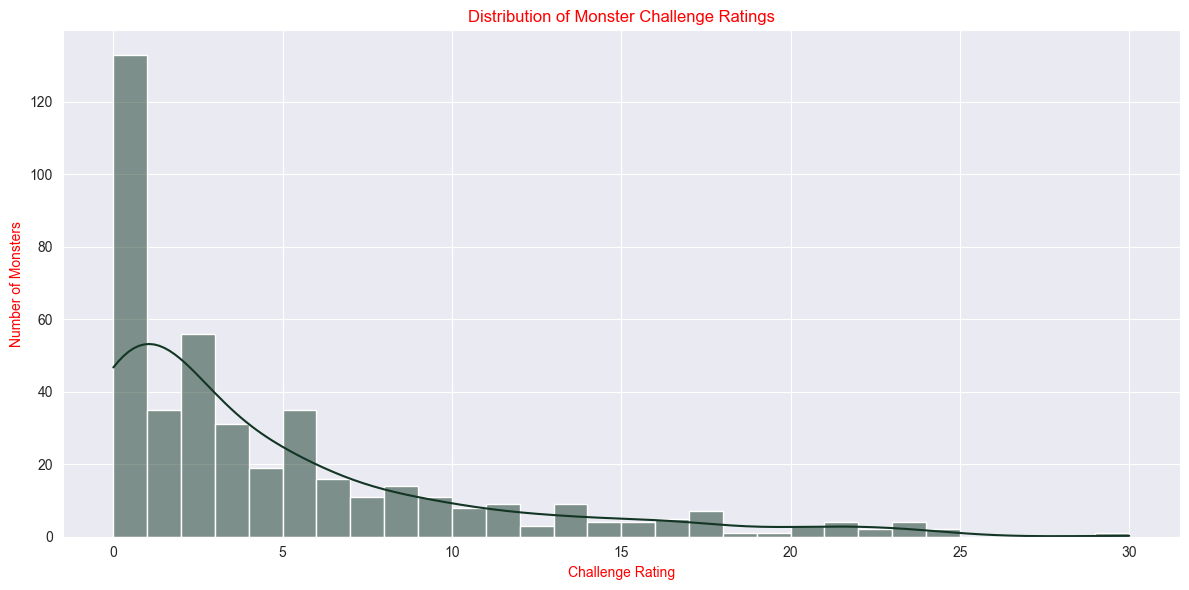

In [6]:
# Visualize CR distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['CR'], bins=30, kde=True, color='#123524')
plt.title("Distribution of Monster Challenge Ratings", color='red')
plt.xlabel('Challenge Rating', color='red')
plt.ylabel('Number of Monsters', color='red')
plt.tight_layout()
plt.show()

### Target Variable Results
Challenge Rating ranges from $0$ to $30$ across $428$ monsters with a $mean$ of $4.55$ and a $median$ of $2.0$, confirming a heavily right skewed distribution. The majority of monsters cluster at low *CR* with a long tail extending toward legendary creatures. This skew is significant and the model will have far more examples to learn from at lower *CR*s than at higher *CR*s. This is expected to affect prediction accuracy at legendary monster levels.

---

### Feature Correlation Analysis
The correlation between each numeric stat and Challenge Rating is calculated to identify which features are most likely to be useful predictors before building the model. Correlation ranges from $-1$ to $1$ where ($1.0$) indicates a perfect positive relationship, ($0.0$) indicates no relationship, and ($-1.0$) indicates a perfect negative relationship.

In [7]:
# Correlation of numeric features with CR
numeric_cols = ['Armor Class', 'Hit Points', 'STR', 'DEX', 'CON', 'INT', 'WIS', 'CHA']

correlations = df[numeric_cols + ['CR']].corr()['CR'].drop('CR').sort_values(ascending=False)

print('Feature Correlations with CR:')
print(correlations)

Feature Correlations with CR:
Hit Points     0.933268
CON            0.824834
Armor Class    0.739156
CHA            0.683857
STR            0.677147
INT            0.604942
WIS            0.536870
DEX            0.013128
Name: CR, dtype: float64


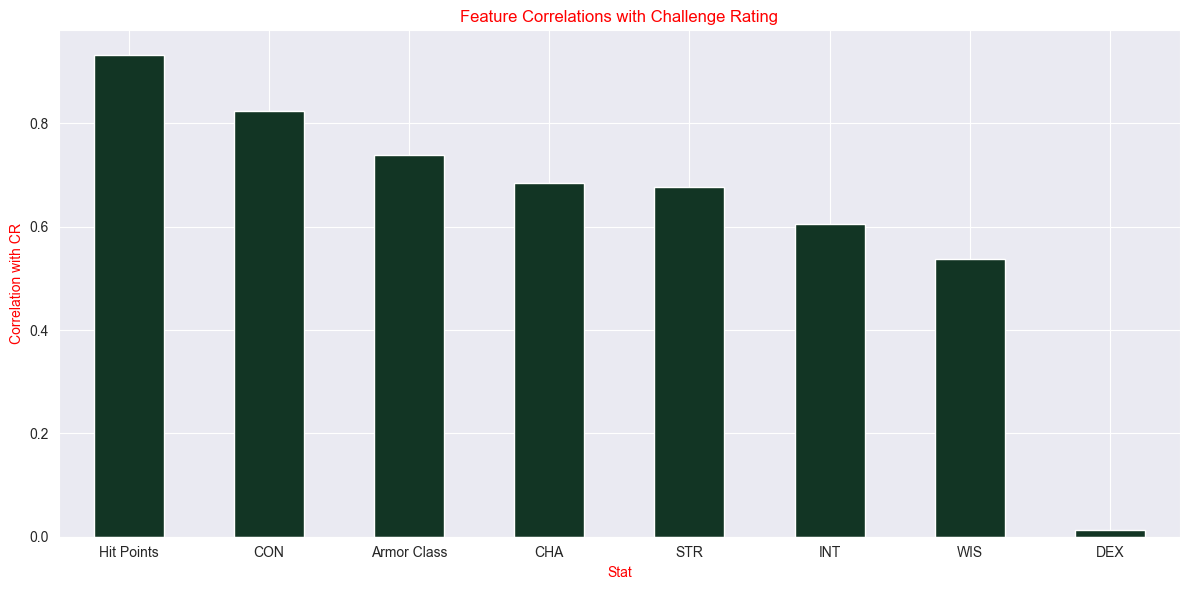

In [8]:
# Visualize feature correlations
plt.figure(figsize=(12, 6))
correlations.plot(kind="bar", color="#123524")
plt.title("Feature Correlations with Challenge Rating", color='red')
plt.xlabel("Stat", color='red')
plt.ylabel("Correlation with CR", color='red')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Feature Correlation Results
*HP* shows the strongest correlation with *CR* at $0.93$, making it the dominant predictor before any modeling takes place. *CON* follows at $0.82$, likely reflecting its direct influence on Hit Points. *AC, CHA, STR, INT,* and *WIS* all show moderate to strong positive correlations ranging from $0.74$ down to $0.54$. *DEX* shows a correlation of $0.01$, which is effectively zero and suggests no meaningful linear relationship with Challenge Rating (*This is the first indication that the official CR system may ignore a stat that directly affects combat difficulty*).

---

### Feature Relationships
Scatter plots of each stat against Challenge Rating are generated to visualize the shape of each relationship and confirm correlation.

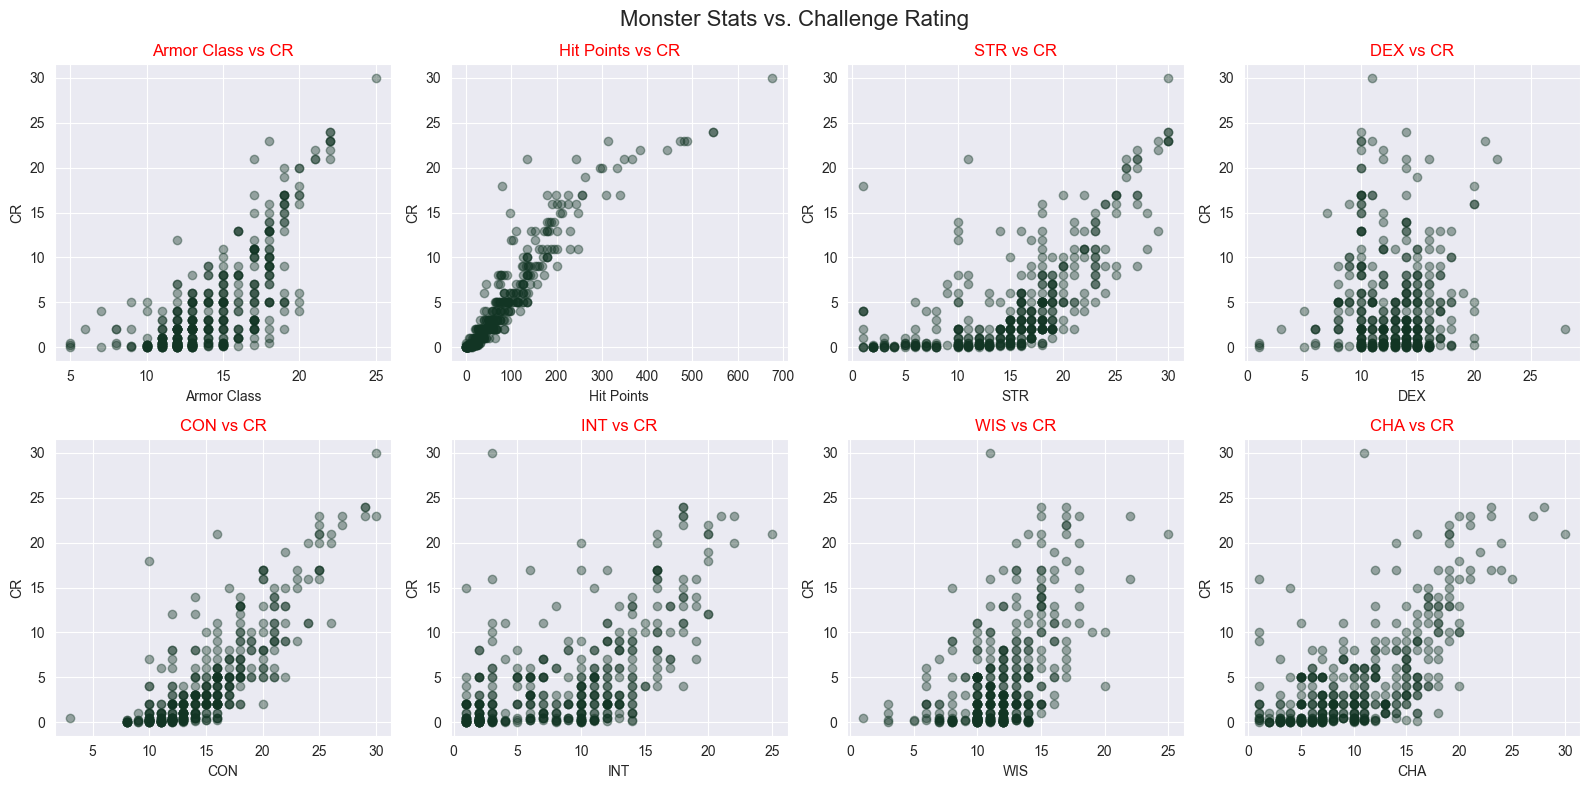

In [9]:
# Feature vs CR plots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(df[col], df['CR'], alpha=0.4, color='#123524')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('CR')
    axes[i].set_title(f'{col} vs CR', color='red')

plt.suptitle("Monster Stats vs. Challenge Rating", fontsize=16)
plt.tight_layout()
plt.show()

### Feature Relationship Results
Seven of the eight stats show a clear upward trend confirming positive correlation with *CR*. *HP* displays the tightest and most consistent upward trend, reinforcing its dominance as a predictor. *DEX* displays a symmetrical random distribution with no discernible pattern, visually confirming the near zero correlation found in the previous analysis. The sparse population of dots at high CR values across all plots reflects the right skewed distribution of the dataset and foreshadows potential limitations in model accuracy at legendary monster levels.

---

### Model Preparation
The dataset is divided into features and a target variable before being split into training and test sets. The eight numeric stats serve as *features* and CR serves as the *target variable*. An 80/20 split allocates 342 monsters to the training set and 86 monsters to the test set. (*The test set contains monsters the model never sees during training, providing an honest measure of how well the model generalizes to unseen data*).

In [10]:
# Define features and target
features = numeric_cols
X = df[features]
y = df['CR']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} monsters")
print(f"Test set size: {len(X_test)} monsters")

Training set size: 342 monsters
Test set size: 86 monsters


### Model Training
A *Random Forest* Regressor is trained on the training set using 100 decision trees. Random Forest was selected for this analysis because it handles non-linear relationships between the stats and CR, performs well on small datasets, requires minimal tuning, and provides feature importance scores that are crucial for the goals of this project. The random state is fixed at 42 to ensure reproducibility.

In [11]:
# Build and train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


### Model Evaluation
The trained model is evaluated against the 86 monsters in the test set using two metrics. ***Mean Absolute Error*** ($MAE$) measures the average number of CR levels the prediction differs from the actual value, where lower is better. ***R$^2$*** measures the proportion of CR variation the model explains, where $1.0$ represents a perfect fit.

In [12]:
# Model evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.2f}')

Mean Absolute Error: 0.75
R^2 Score: 0.97


### Model Evaluation Results
The model achieves an $R^2$ of $0.97$ and a *(MAE)* of $0.75$ CR levels.
On average the model predicts Challenge Rating within less than one CR level, and the model accounts for 97% of all variation in CR across the test set. These results confirm that a monster's raw stat block largely determines its Challenge Rating and that the Random Forest model has effectively learned the patterns of the official rating system.

---

### Predicted vs Actual CR

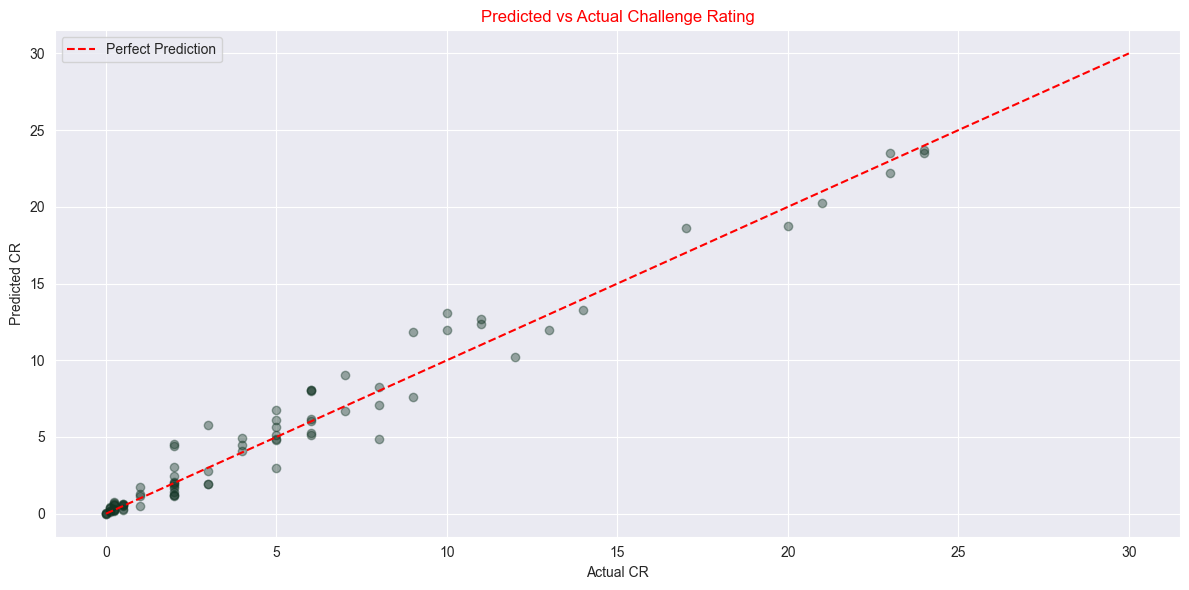

In [13]:
# Predicted vs Actual CR plot
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#123524')
plt.plot([0, 30], [0, 30], color='red', linestyle='--', label='Perfect Prediction')
plt.title("Predicted vs Actual Challenge Rating", color='red')
plt.xlabel('Actual CR')
plt.ylabel('Predicted CR')
plt.legend()
plt.tight_layout()
plt.show()

The model's predictions are plotted against the actual CR values for all 86 monsters in the test set. Each point represents one monster. The red dashed line represents perfect prediction where the predicted CR exactly matches the actual CR.

The majority of monsters cluster tightly around the perfect prediction line confirming the model's strong overall accuracy. Predictions are most precise at low to-mid CR values where the training set contains the greatest number of examples. At high CR values the scatter around the prediction line increases, reflecting the limited number of legendary monsters available for training. This pattern is consistent with the right skewed distribution identified earlier and represents a meaningful limitation of the model at the high end of the CR scale.

---

### Feature Importance Analysis
Feature importance scores extracted from the trained Random Forest model quantify the contribution of each stat to CR prediction.

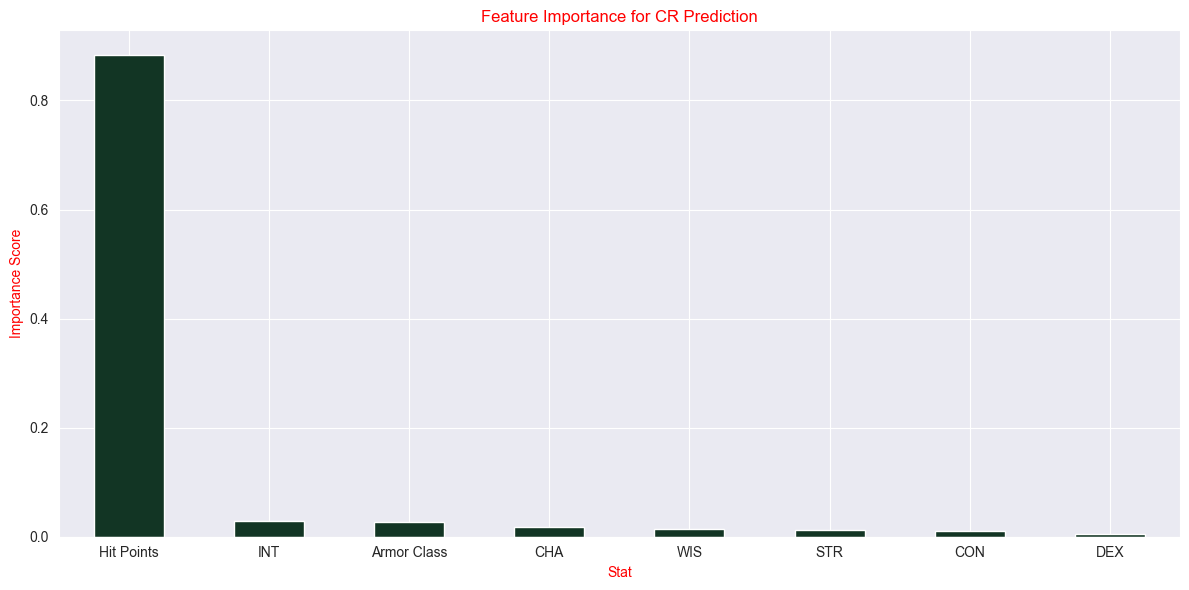


Feature Importance Scores:
Hit Points     0.884214
INT            0.028327
Armor Class    0.027203
CHA            0.017899
WIS            0.013769
STR            0.012160
CON            0.011016
DEX            0.005413
dtype: float64


In [14]:
# Feature Importance
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importance.plot(kind='bar', color='#123524')
plt.title("Feature Importance for CR Prediction", color='red')
plt.xlabel('Stat', color='red')
plt.ylabel('Importance Score', color='red')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'\nFeature Importance Scores:')
print(importance)

### Feature Importance Results
*HP* accounts for $88.4%$ of the model's predictive power, establishing the official CR system as fundamentally an HP scaling system. *INT, AC, CHA, WIS, STR, and CON* each contribute between $1%$ and $3%$, reflecting modest but measurable influence on CR. *DEX* contributes only $0.5%$, confirming the near zero correlation identified earlier and establishing that the official system almost entirely disregards a stat that directly affects how difficult a monster is to hit and how quickly it acts in combat.

The low contribution of Constitution despite its strong correlation with *CR* is worth noting. *CON* directly influences *HP* in the fifth edition ruleset, and the disparity in their importance scores may point to multicollinearity between the two features. This relationship warrants further investigation in future analysis.

---

## Discussion
The results of this analysis reveal several meaningful insights into the structure of the fifth edition Challenge Rating system. The model's high accuracy confirms that raw stat blocks are largely sufficient to reproduce official CR values, suggesting the rating system follows consistent internal logic even if that logic produces inconsistent encounter difficulty in practice.

The dominance of Hit Points as a predictor is the most significant finding. A system that derives $88%$ of its ratings from a single stat is vulnerable to edge cases where that stat does not accurately represent danger. A monster with very high Hit Points but low offensive output will be rated higher than its actual threat level, while a monster with low Hit Points but devastating attacks or high Dexterity may be underrated.

The near absence of Dexterity from the model's predictive framework is a notable limitation of the official system. Dexterity affects Armor Class for unarmored monsters, initiative order, and Dexterity saving throw dice checks, all of which directly influence encounter difficulty. Its effective exclusion from CR calculation represents a systematic gap in the rating system.

The model's reduced accuracy at high CR values is an expected limitation given the right skewed distribution of the dataset. Legendary monsters are rare by design, and the small number of high CR training examples limits the model's ability to generalize at that range. A larger dataset incorporating homebrew or third party monsters at high CR levels could improve performance in future work.

The exclusion of *Speed, Type, Alignment*, and *Special Abilities* from this analysis represents an additional limitation. These features may account for some of the residual variance not captured by raw stats alone and represent a natural direction for future investigation.

---

## Conclusion
This project demonstrates that a Random Forest regression model trained on raw stat blocks can predict fifth edition Challenge Rating with an $R^2$ of $0.97$ and a Mean Absolute Error *(MAE)* of $0.75$ CR levels. The analysis confirms that the official CR system is largely consistent with raw stats but relies disproportionately on Hit Points, which accounts for $88.4%$ of predictive power. Dexterity contributes only $0.5%$ to model predictions despite its direct relevance to combat difficulty, representing a systematic gap in the official rating system. These findings provide a data driven explanation for why CR can feel unreliable at the table and establish a foundation for a predictive tool that Dungeon Masters can use to evaluate custom monster designs. Future work will incorporate additional features, expand the dataset, and develop an interactive application for practical use.

---

## References
Dataset: Hernandez, Jairo. "D&D 5e Monster Stats." Kaggle, 2023,
    www.kaggle.com/datasets/jairohernandez/d-and-d-5e-monster-stats.
    Accessed May 2026.

| Library      | Version  | Source             |
|--------------|----------|--------------------|
| pandas       | 3.0.2    | pandas.pydata.org  |
| numpy        | 2.4.4    | numpy.org          |
| matplotlib   | 3.10.9   | matplotlib.org     |
| seaborn      | 0.13.2   | seaborn.pydata.org |
| scikit-learn | 1.8.0    | scikit-learn.org   |
| Python       | 3.12     | python.org         |

---

### Model Export
To deploy the trained model in the Streamlit application, serialize it to disk
using the following command. This step only needs to be run once or following
any retraining. The resulting `.pkl` file is excluded from version control.

```python
import joblib
joblib.dump(model, "cr_predictor_model.pkl")
```